Langkah 1 : Instalasi dan Import Library

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

shap.initjs()

Langkah 2 : Menyiapkan Data Simulasi

In [ ]:
np.random.seed(42)
n_samples = 300

x = pd.DataFrame({
    "usia_bangunan": np.random.randint(1, 30, n_samples),
    "anggota_keluarga": np.random.randint(2, 7, n_samples),
    "paparan_matahari": np.random.uniform(3, 8, n_samples),
    "index_isolasi_panas": np.random.uniform(0.3, 0.9, n_samples)
})

y = (
    100000 +  # biaya dasar (Rp)
    150000 * x["anggota_keluarga"] +
    5000 * x["usia_bangunan"] +
    -20000 * x["paparan_matahari"] +
    -80000 * x["index_isolasi_panas"] +
    np.random.normal(0, 20000, n_samples)
)

# Split data
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)


Langkah 3 : Melatih Model dan Inisialisasi Explainer

In [104]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_train)

Langkah 4 Visualisasi Global 

/tmp/ipykernel_10485/876136214.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,x_train)


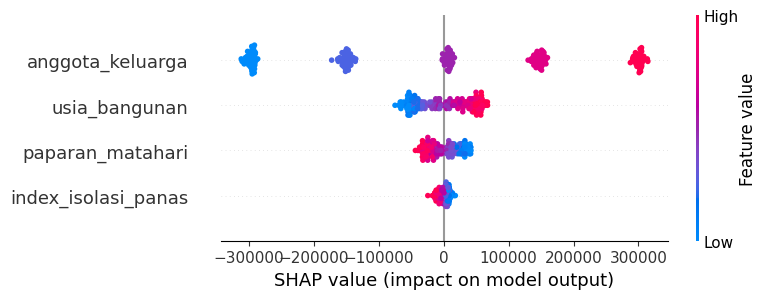

In [105]:
shap.summary_plot(shap_values,x_train)

Feature Importance 

/tmp/ipykernel_10485/1342205103.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_train, plot_type="bar")


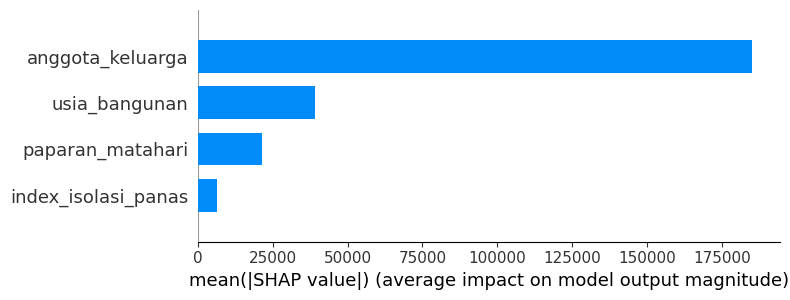

In [106]:
shap.summary_plot(shap_values, x_train, plot_type="bar")

Force Plot

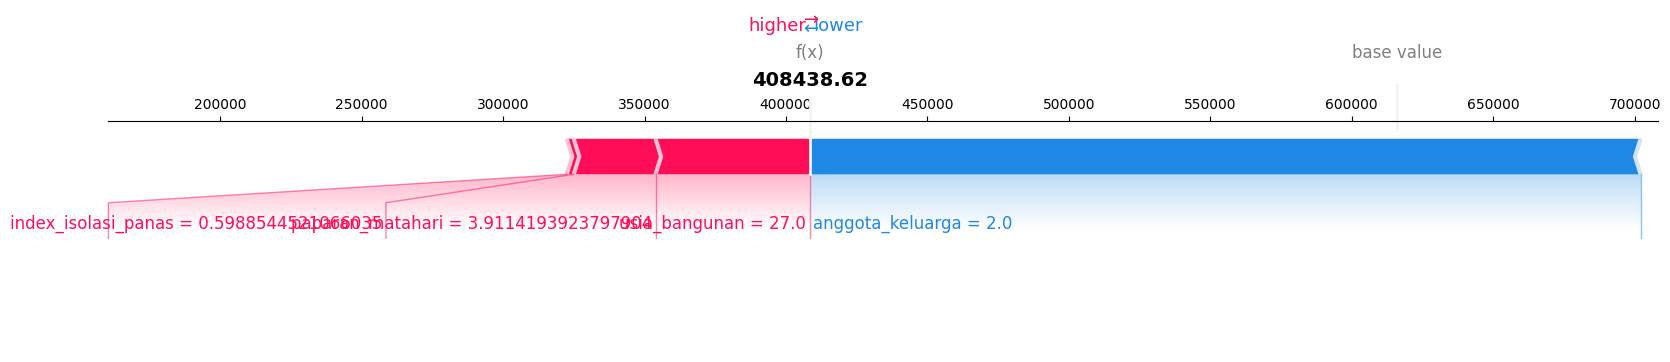

In [107]:
shap.plots.force(explainer.expected_value, shap_values[0], x_train.iloc[0], matplotlib="True")

Prediksi dan evaluasi

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(x_test)
\
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 24904.932947180783
RMSE: 30110.866690363582
R2  : 0.9814496657968882
